# Maliar–Maliar–Winant Deep Learning Method: Krusell–Smith Model in Julia

This notebook follows the teaching order of RBC.ipynb:

1. introduce the economic model;
2. define and draw the neural-network policy;
3. derive the loss function;
4. show how simulated training data are generated;
5. train the network;
6. evaluate the solution.

We follow the continuous-shock finite-agent Krusell–Smith example in Maliar, Maliar, and Winant (2021), rather than the original paper's two-state employment process.

## 1) Krusell–Smith Heterogeneous-Agent Model

### 1.1 Household problem

Household $i$ chooses consumption and next-period capital:

$$
\max E_0\sum_{t=0}^{\infty}\beta^t
\frac{(c_t^i)^{1-\gamma}-1}{1-\gamma}
$$

subject to

$$
c_t^i+k_{t+1}^i=w_t^i,
\qquad k_{t+1}^i\ge0,
$$

$$
w_{t+1}^i=(1-\delta+r_{t+1})k_{t+1}^i
+q_{t+1}y_{t+1}^i.
$$

Cash on hand $w_t^i$ is split between current consumption and savings. The inequality $k_{t+1}^i\ge0$ is the no-borrowing constraint.

### 1.2 Production and prices

Per-household aggregate capital is

$$
K_t=\frac{1}{N}\sum_{i=1}^N k_t^i.
$$

Mean labor productivity is normalized to one, so output and competitive prices are

$$
Y_t=z_tAK_t^\alpha,
$$

$$
r_t=z_tA\alpha K_t^{\alpha-1},
\qquad
q_t=z_tA(1-\alpha)K_t^\alpha.
$$

Household decisions determine $K_{t+1}$. Aggregate capital determines next-period prices, and prices determine every household's next-period wealth.

### 1.3 Shocks and the state

Idiosyncratic and aggregate productivity follow log AR(1) processes:

$$
\log y_{t+1}^i
=\rho_y\log y_t^i+\sigma_y\epsilon_{y,t+1}^i-d_y,
\qquad \epsilon_{y,t+1}^i\sim N(0,1),
$$

$$
\log z_{t+1}
=\rho_z\log z_t+\sigma_z\epsilon_{z,t+1}-d_z,
\qquad \epsilon_{z,t+1}\sim N(0,1).
$$

The drift corrections center productivity levels near one. The code truncates productivity at two unconditional standard deviations and normalizes the cross-sectional mean of $y_{t+1}^i$ to one.

The complete state is

$$
s_t=(W_t,Y_t,z_t)
=((w_t^1,\ldots,w_t^N),(y_t^1,\ldots,y_t^N),z_t),
$$

with dimension $2N+1$.

### 1.4 Euler equation and borrowing constraint

Let $\mu_t^i$ denote the normalized multiplier. The Euler condition is

$$
\mu_t^i
=\beta E_t\left[
\left(\frac{c_t^i}{c_{t+1}^i}\right)^\gamma
(1-\delta+r_{t+1})
\right].
$$

The Kuhn–Tucker conditions are

$$
k_{t+1}^i\ge0,\qquad
\mu_t^i-1\ge0,\qquad
k_{t+1}^i(\mu_t^i-1)=0.
$$

If savings are positive, $\mu_t^i=1$. If the household is borrowing constrained, $k_{t+1}^i=0$ and $\mu_t^i>1$.

## 2) Julia Setup

This is a teaching notebook, so the economically important implementation stays visible here:

- model calibration and steady state;
- the hand-written neural network;
- policy and state-transition functions;
- Euler/AiO loss;
- Adam and the training loop.

Only supporting material stays in src:

- NetworkDiagram.jl: architecture and training-flow diagrams;
- Diagnostics.jl: repetitive evaluation and plotting helpers.

In [21]:
using Pkg

function find_project_root(start_dir=pwd())
    dir = abspath(start_dir)
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && error("Could not find Project.toml from $(start_dir)")
        dir = parent
    end
end

project_root = find_project_root()
Pkg.activate(project_root)

using Random
using LinearAlgebra
using Statistics
using Printf
using Flux
using Plots
using Markdown

include(joinpath(project_root, "src", "NetworkDiagram.jl"))

  Activating project at `c:\Users\86132\Desktop\Yuxuan ZHAO\minnesota\Research\DeepLearningMacro`


plot_ks_training_flow_diagram

## 3) Calibration and Steady State

At $y^i=z=1$, the deterministic steady state satisfies

$$
\frac{1}{\beta}
=1-\delta+\alpha AK_{ss}^{\alpha-1}.
$$

Then

$$
Y_{ss}=AK_{ss}^{\alpha},
\qquad
C_{ss}=Y_{ss}-\delta K_{ss},
$$

$$
W_{ss}=Y_{ss}+(1-\delta)K_{ss},
\qquad
\xi_{ss}=\frac{C_{ss}}{W_{ss}}.
$$

The teaching configuration uses $N=10$ agents and $H=16$ neurons per hidden layer. The reference implementation uses a larger network and a much longer training run.

In [22]:
"""
Calibration and numerical choices for the Maliar--Maliar--Winant deep-learning
solution of the Krusell--Smith economy.

The state contains cash on hand and idiosyncratic labor productivity for every
agent, plus aggregate productivity. Set `agents=50` to match the reference code.
"""
Base.@kwdef struct KSParams
    alpha::Float64 = 0.36
    delta::Float64 = 0.08
    A::Float64 = 1.0
    beta::Float64 = 0.96
    gamma::Float64 = 1.0

    rho_z::Float64 = 0.90
    sigma_z::Float64 = 0.01
    rho_y::Float64 = 0.95
    sigma_y::Float64 = 0.20

    agents::Int = 10
    hidden::Int = 24
    xi_min::Float64 = 1e-4
    xi_max::Float64 = 1.0 - 1e-4
    wealth_cap_multiple::Float64 = 4.0
    productivity_sd_bound::Float64 = 2.0
    mu_log_bound::Float64 = 8.0
end

"""Deterministic steady state with unit labor and aggregate productivity."""
function steady_state(p::KSParams)
    K = ((1 / p.beta - (1 - p.delta)) / (p.alpha * p.A))^(1 / (p.alpha - 1))
    Y = p.A * K^p.alpha
    rental = p.A * p.alpha * K^(p.alpha - 1)
    wage = p.A * (1 - p.alpha) * K^p.alpha
    W = (1 - p.delta + rental) * K + wage
    C = Y - p.delta * K
    xi = C / W
    return (; K, Y, C, W, xi, rental, wage)
end


par = KSParams(agents=10, hidden=16)
ss = steady_state(par)

@printf("Preferences: beta=%.2f, gamma=%.1f\n", par.beta, par.gamma)
@printf("Technology: alpha=%.2f, delta=%.2f\n", par.alpha, par.delta)
@printf("Aggregate shock: rho_z=%.2f, sigma_z=%.3f\n", par.rho_z, par.sigma_z)
@printf("Individual shock: rho_y=%.2f, sigma_y=%.2f\n", par.rho_y, par.sigma_y)
@printf("K_ss=%.4f, W_ss=%.4f, C_ss=%.4f, xi_ss=%.4f\n",
    ss.K, ss.W, ss.C, ss.xi)

Preferences: beta=0.96, gamma=1.0
Technology: alpha=0.36, delta=0.08
Aggregate shock: rho_z=0.90, sigma_z=0.010
Individual shock: rho_y=0.95, sigma_y=0.20
K_ss=5.4468, W_ss=6.8519, C_ss=1.4051, xi_ss=0.2051


## 4) Neural-Network Policy Rule

### 4.1 Input

The same network is used for every household. For household $i$, its input is

$$
x_t^i=
\left[
\widetilde W_t,\widetilde Y_t,\widetilde z_t,
\widetilde w_t^i,\widetilde y_t^i
\right]\in\mathbb R^{2N+3}.
$$

The input contains the full normalized distribution, aggregate productivity, and household $i$'s own state. The own variables appear twice: once inside the distribution and once to identify which household is choosing.

### 4.2 Hidden layers and activation

There are two hidden layers. Both use the logistic sigmoid

$$
\sigma(a)=\frac{1}{1+e^{-a}},
\qquad
\sigma'(a)=\sigma(a)[1-\sigma(a)].
$$

The forward pass is

$$
h_1=\sigma(W_1x_t^i+b_1),
\qquad h_1\in(0,1)^H,
$$

$$
h_2=\sigma(W_2h_1+b_2),
\qquad h_2\in(0,1)^H,
$$

$$
\begin{bmatrix}a_\xi^i\\a_\mu^i\end{bmatrix}
=W_3h_2+b_3.
$$

The last layer is linear and returns two raw numbers.

### 4.3 Parameter storage and initialization

Like RBC.ipynb, we store every weight and bias in one parameter vector $\theta$. The helper below counts parameters, unpacks the vector into matrices, and initializes the two output biases near the deterministic steady state.

In [23]:
logit(x) = log(x / (1 - x))

function sigmoid_stable(x)
    if x >= 0
        q = exp(-x)
        return inv(1 + q)
    else
        q = exp(x)
        return q / (1 + q)
    end
end

input_dimension(p::KSParams) = 2 * p.agents + 3

"""Number of parameters in the two-hidden-layer, two-output network."""
function nparams(p::KSParams)
    D, H = input_dimension(p), p.hidden
    return H * D + H + H * H + H + 2 * H + 2
end

function _unpack(theta, p::KSParams)
    D, H = input_dimension(p), p.hidden
    i = 1
    W1 = reshape(@view(theta[i:(i + H * D - 1)]), H, D)
    i += H * D
    b1 = @view(theta[i:(i + H - 1)])
    i += H
    W2 = reshape(@view(theta[i:(i + H * H - 1)]), H, H)
    i += H * H
    b2 = @view(theta[i:(i + H - 1)])
    i += H
    W3 = reshape(@view(theta[i:(i + 2 * H - 1)]), 2, H)
    i += 2 * H
    b3 = @view(theta[i:(i + 1)])
    return W1, b1, W2, b2, W3, b3
end

"""Small-weight initialization centered on the deterministic policy and mu=1."""
function init_theta(rng::AbstractRNG, p::KSParams, ss=steady_state(p); scale=0.02)
    theta = scale .* randn(rng, nparams(p))
    D, H = input_dimension(p), p.hidden
    b3_start = H * D + H + H * H + H + 2 * H + 1
    theta[b3_start:(b3_start + 1)] .= 0.0
    return theta
end

init_theta

### 4.4 Normalize the state and run the two hidden layers

The next cell constructs the $2N+3$-dimensional input for every household. It then applies

$$
h_1=\sigma(W_1x+b_1),
\qquad
h_2=\sigma(W_2h_1+b_2),
\qquad
a=W_3h_2+b_3.
$$

The tensor construction avoids mutation because next-period inputs depend on $\theta$ and must remain differentiable.

In [24]:
"""A batch of identical deterministic steady states."""
function initial_state(batch_size::Int, p::KSParams, ss=steady_state(p))
    w = fill(ss.W, batch_size, p.agents)
    y = ones(batch_size, p.agents)
    z = ones(batch_size)
    return (; w, y, z)
end

function _state_bounds(p::KSParams, ss)
    y_log_sd = p.sigma_y / sqrt(1 - p.rho_y^2)
    z_log_sd = p.sigma_z / sqrt(1 - p.rho_z^2)
    w_max = p.wealth_cap_multiple * ss.W
    return (; y_log_sd, z_log_sd, w_max)
end

function _normalize_state(w, y, z, p::KSParams, ss)
    bounds = _state_bounds(p, ss)
    normw = 2 .* w ./ bounds.w_max .- 1
    normy = log.(max.(y, 1e-12)) ./ max(p.productivity_sd_bound * bounds.y_log_sd, 1e-8)
    normz = log.(max.(z, 1e-12)) ./ max(p.productivity_sd_bound * bounds.z_log_sd, 1e-8)
    return normw, normy, normz
end

"""
Construct the paper's full-distribution input. Each column contains all agents'
normalized wealth and productivity, aggregate productivity, and agent i's own
wealth and productivity.
"""
function _network_input(w, y, z, p::KSParams, ss)
    B, N = size(w)
    N == p.agents || throw(DimensionMismatch("state has $N agents; parameters expect $(p.agents)"))
    size(y) == size(w) || throw(DimensionMismatch("w and y must have the same shape"))
    length(z) == B || throw(DimensionMismatch("z must contain one value per batch observation"))

    normw, normy, normz = _normalize_state(w, y, z, p, ss)
    # Mutation-free construction is required because next-period inputs depend on theta.
    full_w = reshape(
        permutedims(repeat(reshape(normw, B, N, 1), 1, 1, N), (2, 3, 1)),
        N, N * B,
    )
    full_y = reshape(
        permutedims(repeat(reshape(normy, B, N, 1), 1, 1, N), (2, 3, 1)),
        N, N * B,
    )
    aggregate_z = reshape(vec(repeat(reshape(normz, 1, B), N, 1)), 1, N * B)
    own_w = reshape(vec(permutedims(normw, (2, 1))), 1, N * B)
    own_y = reshape(vec(permutedims(normy, (2, 1))), 1, N * B)
    return vcat(full_w, full_y, aggregate_z, own_w, own_y)
end

function _network_raw(theta, x, p::KSParams)
    W1, b1, W2, b2, W3, b3 = _unpack(theta, p)
    h1 = sigmoid_stable.(W1 * x .+ reshape(b1, :, 1))
    h2 = sigmoid_stable.(W2 * h1 .+ reshape(b2, :, 1))
    return W3 * h2 .+ reshape(b3, :, 1)
end

_network_raw (generic function with 1 method)

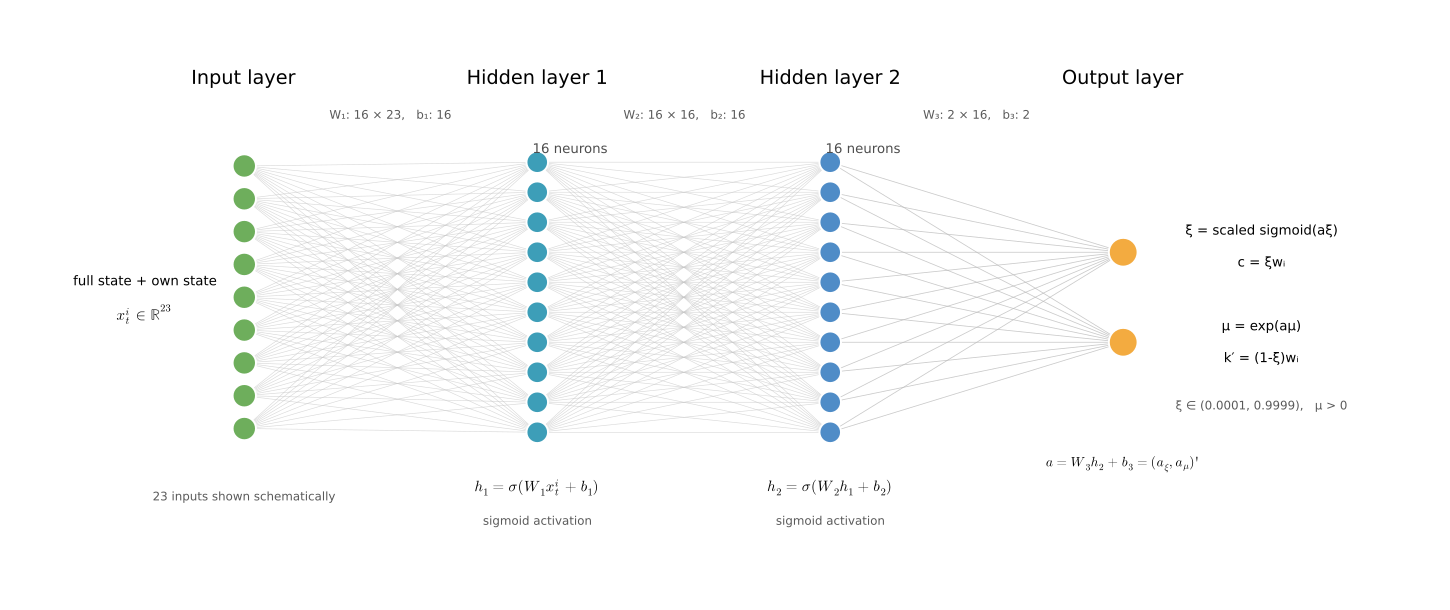

In [25]:
plot_ks_policy_network_diagram(
    agents=par.agents,
    hidden=par.hidden,
    xi_min=par.xi_min,
    xi_max=par.xi_max,
)

### 4.5 Economic output transformations

The raw outputs are transformed into a consumption share and a positive multiplier:

$$
\xi_t^i
=\xi_{min}+(\xi_{max}-\xi_{min})
\sigma\left(a_\xi^i+\operatorname{logit}(\xi_{ss})\right),
$$

$$
\mu_t^i=\exp(a_\mu^i).
$$

Decisions are

$$
c_t^i=\xi_t^iw_t^i,
\qquad
k_{t+1}^i=(1-\xi_t^i)w_t^i.
$$

Therefore consumption is positive, savings are nonnegative, and the budget constraint holds by construction.

### 4.6 Policy implementation

This cell applies the scaled sigmoid and exponential output transformations, then constructs consumption and savings so the household budget constraint holds exactly.

In [26]:
"""Evaluate consumption-share and multiplier policies for a state batch."""
function policy(theta, w, y, z, p::KSParams, ss=steady_state(p))
    B, N = size(w)
    raw = _network_raw(theta, _network_input(w, y, z, p, ss), p)

    qss = (ss.xi - p.xi_min) / (p.xi_max - p.xi_min)
    xi_vector = p.xi_min .+ (p.xi_max - p.xi_min) .* sigmoid_stable.(raw[1, :] .+ logit(qss))
    mu_vector = exp.(clamp.(raw[2, :], -p.mu_log_bound, p.mu_log_bound))
    xi = permutedims(reshape(xi_vector, N, B), (2, 1))
    mu = permutedims(reshape(mu_vector, N, B), (2, 1))

    w_max = p.wealth_cap_multiple * ss.W
    kp = min.((1 .- xi) .* w, w_max)
    c = max.(w .- kp, 1e-10)
    return (; xi, mu, c, kp)
end

policy

In [27]:
theta = init_theta(MersenneTwister(1234), par, ss)
state0 = initial_state(2, par, ss)
policy0 = policy(theta, state0.w, state0.y, state0.z, par, ss)

D = 2 * par.agents + 3
H = par.hidden
@printf("architecture: %d inputs -> %d sigmoid -> %d sigmoid -> 2 outputs\n", D, H, H)
@printf("parameter count: %d\n", nparams(par))
@printf("initial mean xi=%.4f; initial mean mu=%.4f\n",
    mean(policy0.xi), mean(policy0.mu))
@printf("maximum budget error: %.3e\n",
    maximum(abs.(policy0.c .+ policy0.kp .- state0.w)))

architecture: 23 inputs -> 16 sigmoid -> 16 sigmoid -> 2 outputs
parameter count: 690
initial mean xi=0.2078; initial mean mu=0.9782
maximum budget error: 0.000e+00


## 5) Loss Function

### 5.1 Borrowing-constraint loss

Define

$$
a_t^i=\mu_t^i-1,
\qquad
b_t^i=\frac{w_t^i}{c_t^i}-1
=\frac{k_{t+1}^i}{c_t^i}.
$$

The Fisher–Burmeister residual is

$$
\Phi_t^i=a_t^i+b_t^i
-\sqrt{(a_t^i)^2+(b_t^i)^2}.
$$

We have $\Phi_t^i=0$ exactly when

$$
a_t^i\ge0,\qquad b_t^i\ge0,\qquad a_t^ib_t^i=0.
$$

Its loss contribution is $E[(\Phi_t^i)^2]$.

### 5.2 Euler loss and two-shock AiO

For one future shock vector $\epsilon$, define

$$
R_t^i(\epsilon;\theta)
=\beta
\left(\frac{c_t^i}{c_{t+1}^i(\epsilon)}\right)^\gamma
[1-\delta+r_{t+1}(\epsilon)]
-\mu_t^i.
$$

The model requires

$$
E[R_t^i(\epsilon;\theta)\mid s_t]=0.
$$

Squaring one realized residual would also penalize shock variance. Draw two independent future shocks $A$ and $B$ from the same state:

$$
E[R_A^iR_B^i\mid s_t]
=E[R_A^i\mid s_t]E[R_B^i\mid s_t].
$$

Hence the mini-batch loss is

$$
\widehat{\mathcal L}(\theta)
=\frac{1}{BN}\sum_{b=1}^B\sum_{i=1}^N
\left[(\Phi_b^i)^2+R_{A,b}^iR_{B,b}^i\right].
$$

A finite AiO estimate may be negative, but its population target is nonnegative.

### 5.3 Implement shocks, prices, future branches, and the loss

The code below follows the equations above directly:

1. draw idiosyncratic and aggregate shocks;
2. construct next-period productivity;
3. aggregate household savings and compute prices;
4. evaluate the same network at each future branch;
5. combine Fisher–Burmeister and AiO Euler residuals.

In [28]:
"""Draw standardized idiosyncratic and aggregate innovations."""
function draw_shocks(rng::AbstractRNG, batch_size::Int, p::KSParams)
    return (; eps_y=randn(rng, batch_size, p.agents), eps_z=randn(rng, batch_size))
end

"""Advance idiosyncratic and aggregate productivity in levels."""
function transition_productivity(y, z, shocks, p::KSParams)
    bounds = _state_bounds(p, steady_state(p))
    y_bound = p.productivity_sd_bound * bounds.y_log_sd
    z_bound = p.productivity_sd_bound * bounds.z_log_sd

    log_y_next = p.rho_y .* log.(max.(y, 1e-12)) .+
                 p.sigma_y .* shocks.eps_y .-
                 0.5 * p.sigma_y^2 / (1 + p.rho_y)
    log_y_next = clamp.(log_y_next, -y_bound, y_bound)
    y_next_raw = exp.(log_y_next)
    y_next = y_next_raw ./ mean(y_next_raw; dims=2)

    log_z_next = p.rho_z .* log.(max.(z, 1e-12)) .+
                 p.sigma_z .* shocks.eps_z .-
                 0.5 * p.sigma_z^2 / (1 + p.rho_z)
    z_next = exp.(clamp.(log_z_next, -z_bound, z_bound))
    return y_next, z_next
end

"""Competitive prices and next-period cash on hand."""
function next_period(kp, y_next, z_next, p::KSParams)
    B = size(kp, 1)
    aggregate_k = vec(mean(kp; dims=2))
    rental = p.A .* z_next .* p.alpha .* aggregate_k .^ (p.alpha - 1)
    wage = p.A .* z_next .* (1 - p.alpha) .* aggregate_k .^ p.alpha
    gross_return = 1 - p.delta .+ rental
    wealth_next = reshape(gross_return, B, 1) .* kp .+ reshape(wage, B, 1) .* y_next
    return (; aggregate_k, rental, wage, gross_return, wealth_next)
end

function _future_branch(theta, current_policy, y, z, shocks, p::KSParams, ss)
    y_next, z_next = transition_productivity(y, z, shocks, p)
    prices = next_period(current_policy.kp, y_next, z_next, p)
    next_policy = policy(theta, prices.wealth_next, y_next, z_next, p, ss)
    euler = p.beta .* (current_policy.c ./ next_policy.c) .^ p.gamma .*
            reshape(prices.gross_return, :, 1) .- current_policy.mu
    return (; y_next, z_next, prices, next_policy, euler)
end

"""AiO objective components for two conditionally independent shock branches."""
function aio_loss_components(theta, state, shocks_a, shocks_b, p::KSParams, ss=steady_state(p))
    current = policy(theta, state.w, state.y, state.z, p, ss)
    branch_a = _future_branch(theta, current, state.y, state.z, shocks_a, p, ss)
    branch_b = _future_branch(theta, current, state.y, state.z, shocks_b, p, ss)

    a = current.mu .- 1
    b = state.w ./ current.c .- 1
    fisher_burmeister = a .+ b .- sqrt.(a .^ 2 .+ b .^ 2)
    complementarity = mean(fisher_burmeister .^ 2)
    euler = mean(branch_a.euler .* branch_b.euler)
    return (; loss=complementarity + euler, complementarity, euler,
            current, branch_a, branch_b)
end

aio_loss(theta, state, shocks_a, shocks_b, p::KSParams, ss=steady_state(p)) =
    aio_loss_components(theta, state, shocks_a, shocks_b, p, ss).loss

aio_loss (generic function with 2 methods)

In [29]:
rng_loss = MersenneTwister(7)
shock_a = draw_shocks(rng_loss, size(state0.w, 1), par)
shock_b = draw_shocks(rng_loss, size(state0.w, 1), par)
initial_loss = aio_loss_components(theta, state0, shock_a, shock_b, par, ss)

@printf("initial total loss = %.6e\n", initial_loss.loss)
@printf("  Fisher–Burmeister term = %.6e\n", initial_loss.complementarity)
@printf("  AiO Euler term = %.6e\n", initial_loss.euler)

initial total loss = 1.376200e-03
  Fisher–Burmeister term = 4.761257e-04
  AiO Euler term = 9.000743e-04


## 6) Simulation and Training Data

There is no external dataset and no analytical policy label. The model produces its own training observations.

One observation is

$$
\mathcal D_b=
(s_{t,b},\epsilon_{A,b}^y,\epsilon_{A,b}^z,
\epsilon_{B,b}^y,\epsilon_{B,b}^z).
$$

A mini-batch contains $B$ simulated economies. Each economy contains $N$ households and two independent future shock branches.

Given $s_t$:

1. use the NN to compute $\xi_t,\mu_t,c_t,k_{t+1}$;
2. draw shocks and construct $y_{t+1},z_{t+1}$;
3. aggregate capital and compute next-period prices;
4. compute $w_{t+1}$;
5. evaluate the same NN at the next state.

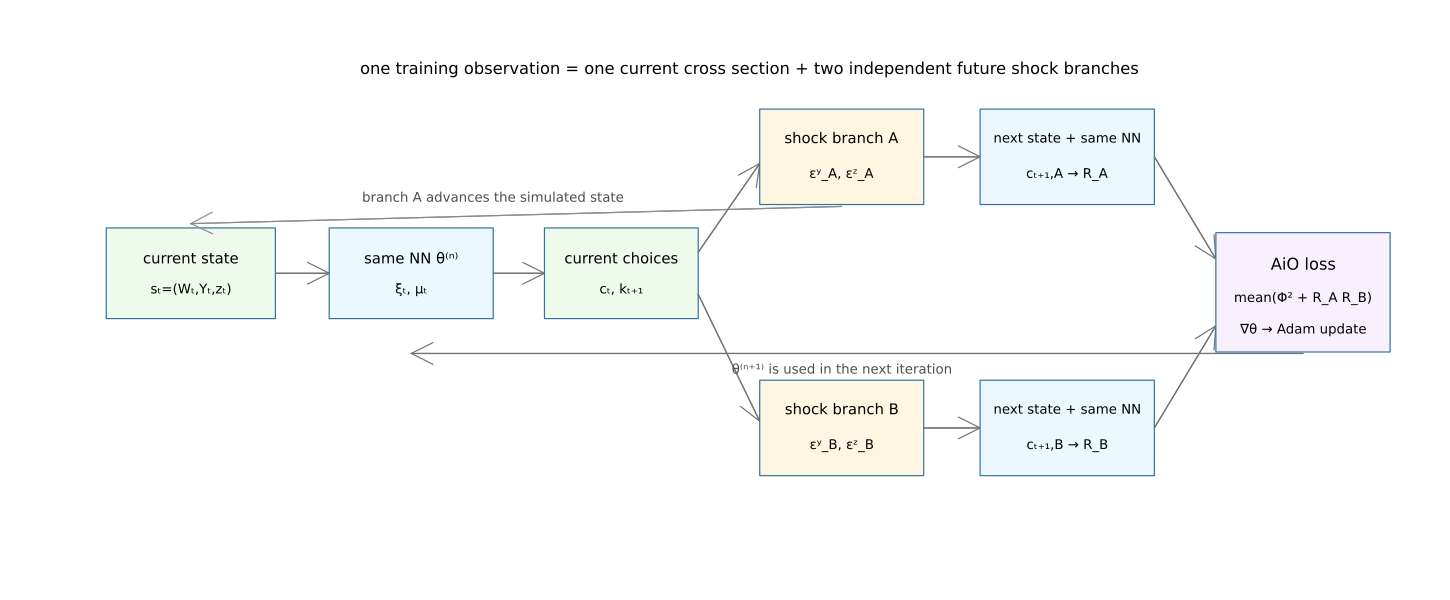

In [30]:
plot_ks_training_flow_diagram()

### 6.1 Generate an endogenous training-state batch

The helper below advances a batch of economies under the current network. It is not an external data loader: it creates the state observations used by the loss.

In [31]:
function _advance_state(theta, state, shocks, p::KSParams, ss)
    current = policy(theta, state.w, state.y, state.z, p, ss)
    y_next, z_next = transition_productivity(state.y, state.z, shocks, p)
    prices = next_period(current.kp, y_next, z_next, p)
    return (; w=prices.wealth_next, y=y_next, z=z_next)
end

"""Generate a stochastic state batch before training, for inspection or warm-up."""
function simulate_training_state(theta, p::KSParams, ss=steady_state(p);
                                 periods=40, batch_size=8, seed=2025)
    rng = MersenneTwister(seed)
    state = initial_state(batch_size, p, ss)
    for _ in 1:periods
        state = _advance_state(theta, state, draw_shocks(rng, batch_size, p), p, ss)
    end
    return state
end

simulate_training_state

In [32]:
# Inspect one simulated training observation before optimization.
preview_state = simulate_training_state(theta, par, ss;
    periods=30, batch_size=4, seed=2025)
preview_rng = MersenneTwister(2026)
preview_a = draw_shocks(preview_rng, 4, par)
preview_b = draw_shocks(preview_rng, 4, par)
preview = aio_loss_components(theta, preview_state, preview_a, preview_b, par, ss)

b, i = 1, 1
@printf("batch shapes: w=%s, y=%s, z=%s\n",
    string(size(preview_state.w)), string(size(preview_state.y)), string(size(preview_state.z)))
@printf("current state: w=%.4f, y=%.4f, z=%.4f\n",
    preview_state.w[b,i], preview_state.y[b,i], preview_state.z[b])
@printf("current policy: xi=%.4f, mu=%.4f, c=%.4f, k'=%.4f\n",
    preview.current.xi[b,i], preview.current.mu[b,i],
    preview.current.c[b,i], preview.current.kp[b,i])
@printf("branch A: next w=%.4f, Euler R=%.4f\n",
    preview.branch_a.prices.wealth_next[b,i], preview.branch_a.euler[b,i])
@printf("branch B: next w=%.4f, Euler R=%.4f\n",
    preview.branch_b.prices.wealth_next[b,i], preview.branch_b.euler[b,i])

batch shapes: w=(4, 10), y=(4, 10), z=(4,)
current state: w=3.2460, y=0.3129, z=1.0053
current policy: xi=0.2078, mu=0.9782, c=0.6747, k'=2.5713
branch A: next w=2.9584, Euler R=0.1174
branch B: next w=3.0585, Euler R=0.0828


## 7) Stochastic Training

At iteration $n$:

1. draw two future shock batches;
2. compute $\widehat{\mathcal L}(\theta^{(n)})$;
3. use automatic differentiation:

   $$
   g^{(n)}=\nabla_\theta
   \widehat{\mathcal L}(\theta^{(n)});
   $$

4. update $\theta$ with Adam;
5. advance the simulated state with branch A;
6. repeat with new shocks.

The NN receives no target consumption data. It learns by reducing equilibrium-condition errors.

### 7.1 Adam and the complete training loop

The full optimizer and training function remain in the notebook. Each iteration draws fresh shocks, differentiates the entire economic calculation with Flux.gradient, updates $\theta$, and advances the simulated state.

In [33]:
mutable struct AdamState
    m::Vector{Float64}
    v::Vector{Float64}
    t::Int
end

AdamState(n::Int) = AdamState(zeros(n), zeros(n), 0)

function _adam_step!(theta, grad, state::AdamState; lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8)
    state.t += 1
    state.m .= beta1 .* state.m .+ (1 - beta1) .* grad
    state.v .= beta2 .* state.v .+ (1 - beta2) .* (grad .^ 2)
    mhat = state.m ./ (1 - beta1^state.t)
    vhat = state.v ./ (1 - beta2^state.t)
    theta .-= lr .* mhat ./ (sqrt.(vhat) .+ eps)
    return theta
end


"""Train on an evolving simulated cross section using the two-shock AiO objective."""
function train!(theta, p::KSParams, ss=steady_state(p);
                steps=300, batch_size=8, lr=1e-3, seed=2026, display_step=50)
    rng = MersenneTwister(seed)
    state = initial_state(batch_size, p, ss)
    optimizer = AdamState(length(theta))
    loss_history = Float64[]
    complementarity_history = Float64[]
    euler_history = Float64[]

    for iteration in 1:steps
        shocks_a = draw_shocks(rng, batch_size, p)
        shocks_b = draw_shocks(rng, batch_size, p)
        loss_function = th -> aio_loss(th, state, shocks_a, shocks_b, p, ss)
        gradient = Flux.gradient(loss_function, theta)[1]
        all(isfinite, gradient) || error("non-finite gradient at iteration $iteration")
        _adam_step!(theta, gradient, optimizer; lr=lr)

        components = aio_loss_components(theta, state, shocks_a, shocks_b, p, ss)
        push!(loss_history, components.loss)
        push!(complementarity_history, components.complementarity)
        push!(euler_history, components.euler)
        state = _advance_state(theta, state, shocks_a, p, ss)

        if iteration == 1 || iteration % display_step == 0
            println("step $(lpad(iteration, 5)) | loss=$(round(components.loss, sigdigits=5)) " *
                    "| FB=$(round(components.complementarity, sigdigits=4)) " *
                    "| AiO Euler=$(round(components.euler, sigdigits=4))")
        end
    end

    return (; theta, state, loss_history, complementarity_history, euler_history)
end

train!

In [34]:
theta = init_theta(MersenneTwister(1234), par, ss)
result = train!(theta, par, ss;
    steps=200,
    batch_size=8,
    lr=1e-3,
    seed=2026,
    display_step=50,
)

step     1 | loss=0.00059668 | FB=0.0001509 | AiO Euler=0.0004457
step    50 | loss=0.0018979 | FB=5.427e-6 | AiO Euler=0.001892
step   100 | loss=0.0018881 | FB=7.378e-6 | AiO Euler=0.001881
step   150 | loss=0.00092293 | FB=8.575e-6 | AiO Euler=0.0009144
step   200 | loss=0.0011819 | FB=3.195e-7 | AiO Euler=0.001182


(theta = [-0.02042164720255119, -0.015060624283424815, -0.008747142980139875, 0.019402221974618376, 0.013620162251563657, 0.06474451854552922, 0.010630137644337623, -0.021624673674594214, -0.006318944772544206, -0.013878904491315408  …  0.0033701953924384948, -0.009432422351812254, -0.0065339196246430855, 0.017671030958369298, -0.00858917809124435, -0.03619035602384902, 0.010557300572869093, -0.0036559030868306723, -0.008625386755180963, 0.0021761487779820795], state = (w = [14.348963572209678 7.291255809659488 … 11.96378757210289 5.265435904595176; 9.322059713086407 3.0962181928570076 … 4.73032564763016 5.9721429588248665; … ; 3.7474928573959625 2.776524871865808 … 8.68711080747562 4.4734907364979675; 3.407032660711982 8.552996376851137 … 3.776898707388062 6.523575467223459], y = [1.9469590839881035 1.3465598434951052 … 1.4333974397904456 0.6855479985818954; 1.0366397622115624 0.44108973625091885 … 0.4061837376828231 0.9010050623001823; … ; 0.42321534665038035 0.3202542493350479 … 0.8

## 8) Diagnostics

Since this model has no closed-form policy benchmark, we check:

- training-loss components;
- out-of-sample conditional Euler errors;
- Fisher–Burmeister errors;
- simulated aggregate capital and capital inequality;
- policy-function slices;
- approximate aggregation.

In [35]:
# Diagnostics are supporting checks rather than the core solution method.
include(joinpath(project_root, "src", "Diagnostics.jl"))

policy_slice

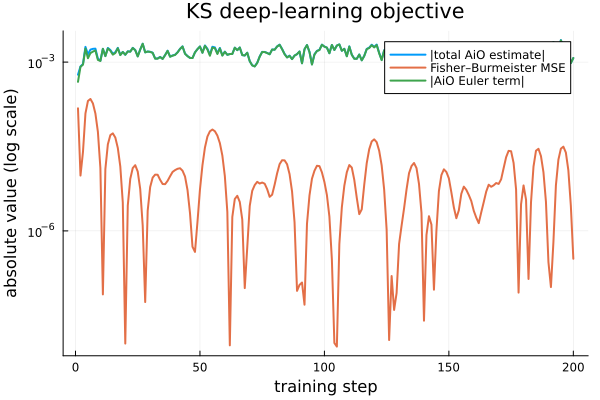

In [36]:
p_loss = plot(abs.(result.loss_history) .+ 1e-14,
    yscale=:log10, lw=2, label="|total AiO estimate|",
    xlabel="training step", ylabel="absolute value (log scale)")
plot!(p_loss, result.complementarity_history .+ 1e-14,
    lw=2, label="Fisher–Burmeister MSE")
plot!(p_loss, abs.(result.euler_history) .+ 1e-14,
    lw=2, label="|AiO Euler term|")
title!(p_loss, "KS deep-learning objective")
p_loss

mean log10 Euler error = -1.6773
median log10 Euler error = -1.6114
p90 log10 Euler error = -1.1542
mean absolute FB residual = 5.1962e-04


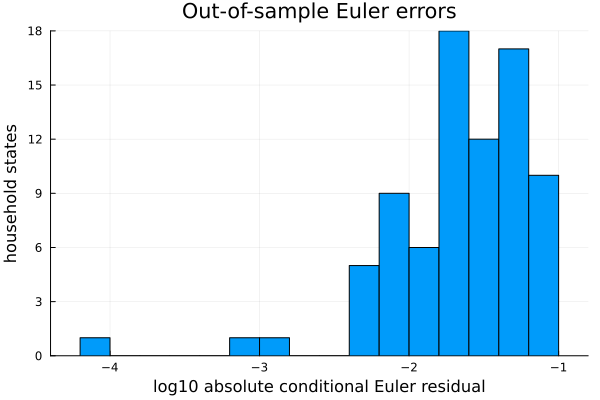

In [37]:
diagnostics = conditional_residuals(result.theta, result.state, par, ss;
    n_shocks=64, seed=99)
log_euler_error = log10.(abs.(vec(diagnostics.euler)) .+ 1e-12)
fb_error = abs.(vec(diagnostics.fisher_burmeister))

@printf("mean log10 Euler error = %.4f\n", mean(log_euler_error))
@printf("median log10 Euler error = %.4f\n", median(log_euler_error))
@printf("p90 log10 Euler error = %.4f\n", quantile(log_euler_error, 0.90))
@printf("mean absolute FB residual = %.4e\n", mean(fb_error))

histogram(log_euler_error, bins=25, label=false,
    xlabel="log10 absolute conditional Euler residual",
    ylabel="household states",
    title="Out-of-sample Euler errors")

mean aggregate capital = 5.9141 (steady state 5.4468)
mean capital Gini = 0.2570
approximate-aggregation R² = 0.98696
log K(t+1) = 0.3184 + 0.8199 log K(t) + 0.2385 log z(t)


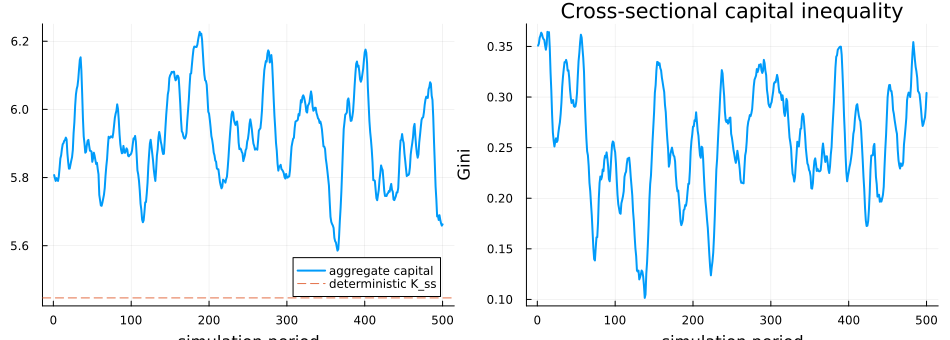

In [38]:
simulation = simulate_economy(result.theta, par, ss;
    periods=500, burn=100, seed=404)
aggregation = approximate_aggregation(simulation)

@printf("mean aggregate capital = %.4f (steady state %.4f)\n",
    mean(simulation.aggregate_k), ss.K)
@printf("mean capital Gini = %.4f\n", mean(simulation.capital_gini))
@printf("approximate-aggregation R² = %.5f\n", aggregation.r2)
@printf("log K(t+1) = %.4f + %.4f log K(t) + %.4f log z(t)\n",
    aggregation.coefficients...)

p_k = plot(simulation.aggregate_k, lw=2, label="aggregate capital",
    xlabel="simulation period")
hline!(p_k, [ss.K], ls=:dash, label="deterministic K_ss")
p_g = plot(simulation.capital_gini, lw=2, label=false,
    xlabel="simulation period", ylabel="Gini",
    title="Cross-sectional capital inequality")
plot(p_k, p_g, layout=(1, 2), size=(950, 340))

### 8.4 Consumption and savings rules

Hold one simulated distribution fixed. Vary household 1's cash on hand and productivity, and evaluate the trained common policy. Each curve still conditions on the complete distribution.

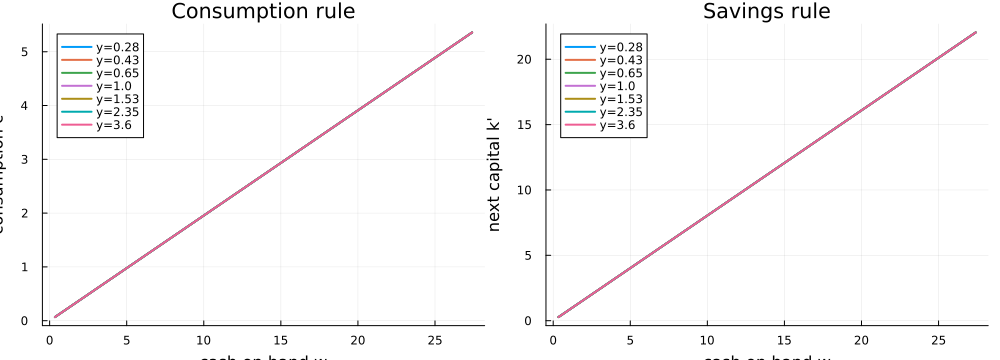

In [39]:
slice = policy_slice(result.theta, simulation.final_state, par, ss;
    agent=1, points=100, productivity_points=7)

p_c = plot(xlabel="cash on hand w", ylabel="consumption c",
    title="Consumption rule")
p_s = plot(xlabel="cash on hand w", ylabel="next capital k'",
    title="Savings rule")
for j in eachindex(slice.productivity_grid)
    label = "y=$(round(slice.productivity_grid[j], digits=2))"
    plot!(p_c, slice.wealth_grid, slice.consumption[:, j], lw=2, label=label)
    plot!(p_s, slice.wealth_grid, slice.savings[:, j], lw=2, label=label)
end
plot(p_c, p_s, layout=(1, 2), size=(1000, 360))

In [40]:
Markdown.parse("""
## 9) Takeaways from the quick run

- Median conditional Euler error: **$(round(median(log_euler_error), digits=3)) log10 units**.
- 90th-percentile Euler error: **$(round(quantile(log_euler_error, 0.90), digits=3)) log10 units**.
- Mean absolute Fisher–Burmeister residual: **$(round(mean(fb_error), sigdigits=4))**.
- Mean capital Gini: **$(round(mean(simulation.capital_gini), digits=3))**.
- Approximate-aggregation regression: **R²=$(round(aggregation.r2, digits=5))**.

These values validate the teaching configuration only. A quantitative research result requires more agents, a larger network, substantially more training steps, multiple random seeds, and more evaluation shocks.
""")

## 9) Takeaways from the quick run

  * Median conditional Euler error: **-1.611 log10 units**.
  * 90th-percentile Euler error: **-1.154 log10 units**.
  * Mean absolute Fisher–Burmeister residual: **0.0005196**.
  * Mean capital Gini: **0.257**.
  * Approximate-aggregation regression: **R²=0.98696**.

These values validate the teaching configuration only. A quantitative research result requires more agents, a larger network, substantially more training steps, multiple random seeds, and more evaluation shocks.
